# Data Understanding

Pada tahap ini dilakukan eksplorasi terhadap **200 artikel berita Indonesia** yang telah dikumpulkan dari detik.com (100 `sport`, id 1-100; 100 `finance`, id 101-200), untuk memahami karakteristik data sebelum masuk ke tahap Data Preparation dan Modeling.

**Aktivitas utama:**
- **Collect Data** - memuat dataset hasil crawling
- **Describe Data** - ringkasan struktur, tipe data, dan statistik dasar
- **Explore Data** - analisis pola, distribusi, dan visualisasi
- **Verify Data Quality** - pengecekan outlier dan kualitas data secara keseluruhan

## 1. Collect Data

Dataset dimuat dari hasil crawling yang telah disimpan (lihat proses lengkapnya di halaman **Data Preparation**).

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import display

df = pd.read_excel("../data/dataset_berita_200.xlsx")
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (200, 4)


,id,isi_berita,label,url
0,1,Chef de Mission (CdM) Indonesia Todotua Pasari...,sport,https://sport.detik.com/sport-lain/d-8655308/c...
1,2,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport,https://sport.detik.com/sport-lain/d-8655303/a...
2,3,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport,https://sport.detik.com/sport-lain/d-8655067/k...
3,4,Persaingan titel juara dunia semakin ketat men...,sport,https://sport.detik.com/moto-gp/d-8654776/moto...
4,5,Sektor ganda campuran kembali mengalami peromb...,sport,https://sport.detik.com/raket/d-8654666/ganda-...


## 2. Describe Data

In [37]:
print("Info dataset:")
df.info()

print("\nDistribusi label:")
print(df["label"].value_counts())

print("\nCek nilai kosong:")
print(df.isnull().sum())

print("\nCek duplikat isi_berita:")
print(df["isi_berita"].duplicated().sum())

Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          200 non-null    int64
 1   isi_berita  200 non-null    str  
 2   label       200 non-null    str  
 3   url         200 non-null    str  
dtypes: int64(1), str(3)
memory usage: 6.4 KB

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64

Cek nilai kosong:
id            0
isi_berita    0
label         0
url           0
dtype: int64

Cek duplikat isi_berita:
0


## 3. Explore Data

### Statistik Panjang Teks

In [38]:
df["panjang_teks"] = df["isi_berita"].apply(len)

print("Statistik panjang teks (karakter):")
print(df.groupby("label")["panjang_teks"].describe())

Statistik panjang teks (karakter):
         count     mean          std    min     25%     50%      75%     max
label                                                                       
finance  100.0  2596.74  1327.979308  826.0  1874.5  2291.0  2863.75  8169.0
sport    100.0  2274.33   812.942343  996.0  1704.0  2131.5  2630.50  5554.0


### Distribusi Panjang Teks

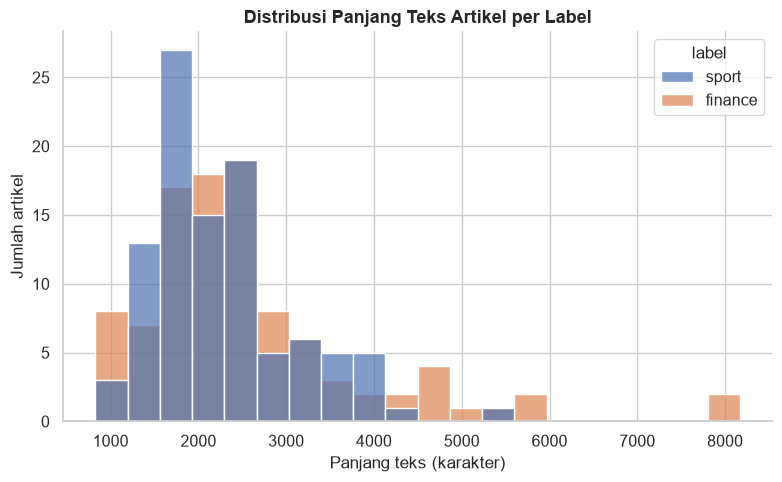

In [39]:
sns.set_theme(style="whitegrid", font_scale=1.05)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="panjang_teks", hue="label",
             palette={"sport": "#4C72B0", "finance": "#DD8452"},
             bins=20, alpha=0.7, ax=ax)
ax.set_title("Distribusi Panjang Teks Artikel per Label", fontsize=13, fontweight="bold")
ax.set_xlabel("Panjang teks (karakter)")
ax.set_ylabel("Jumlah artikel")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Sebaran Panjang Teks per Label

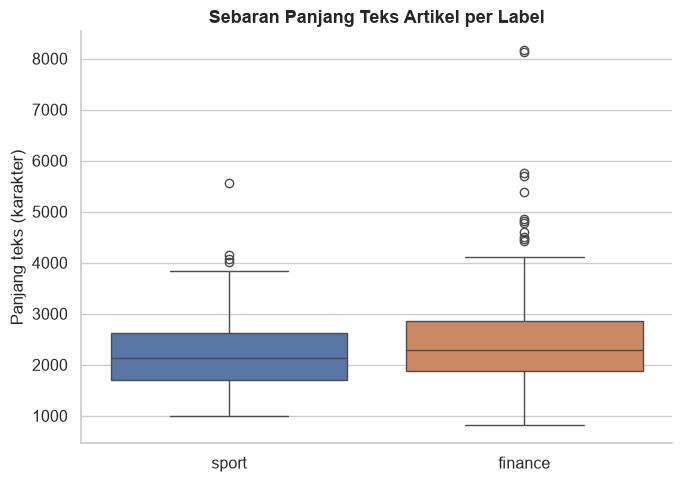

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x="label", y="panjang_teks", hue="label",
            palette={"sport": "#4C72B0", "finance": "#DD8452"},
            legend=False, ax=ax)

ax.set_title("Sebaran Panjang Teks Artikel per Label", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Panjang teks (karakter)")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Distribusi Sub-Kategori

In [41]:
def ambil_subkanal(url):
    match = re.search(r"detik\.com/([a-z0-9-]+)/d-", url)
    return match.group(1) if match else "lainnya"

df["sub_kategori"] = df["url"].apply(ambil_subkanal)

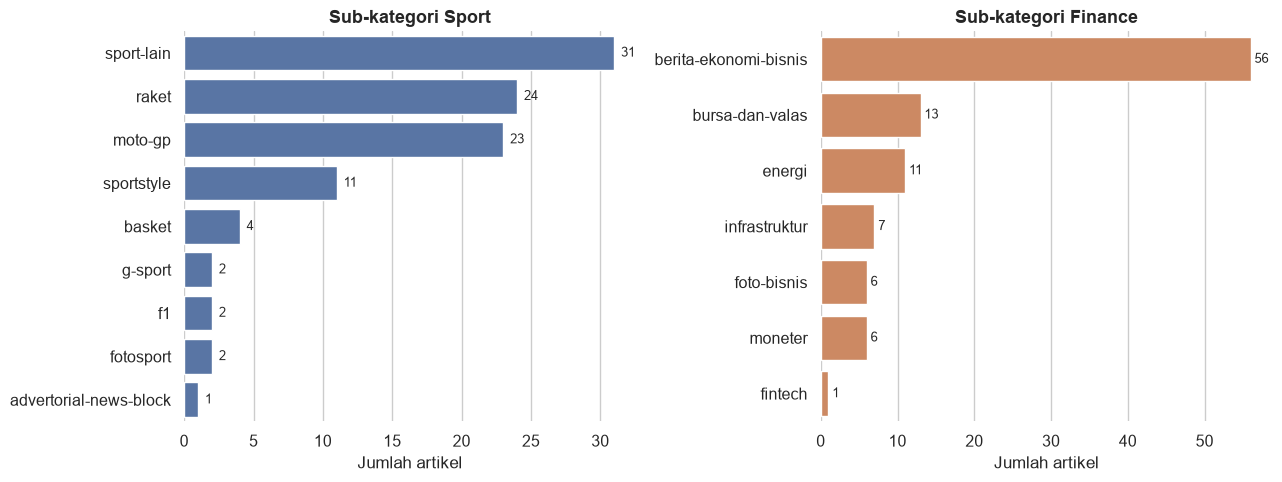

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, kategori, warna in zip(axes, ["sport", "finance"], ["#4C72B0", "#DD8452"]):
    data = df[df["label"] == kategori]["sub_kategori"].value_counts()
    sns.barplot(x=data.values, y=data.index, ax=ax, color=warna)
    ax.set_title(f"Sub-kategori {kategori.capitalize()}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Jumlah artikel")
    ax.set_ylabel("")
    for i, v in enumerate(data.values):
        ax.text(v + 0.5, i, str(v), va="center", fontsize=9)
    sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

### Word Cloud per Kategori

Visualisasi kata-kata yang paling sering muncul di tiap kategori. Stopword (kata sambung seperti "yang", "dan", "dari") dihilangkan **khusus untuk visualisasi ini** agar kata bermakna lebih terlihat jelas — ini bukan bagian dari pipeline preprocessing/klasifikasi yang akan dikerjakan pada tahap Modeling.

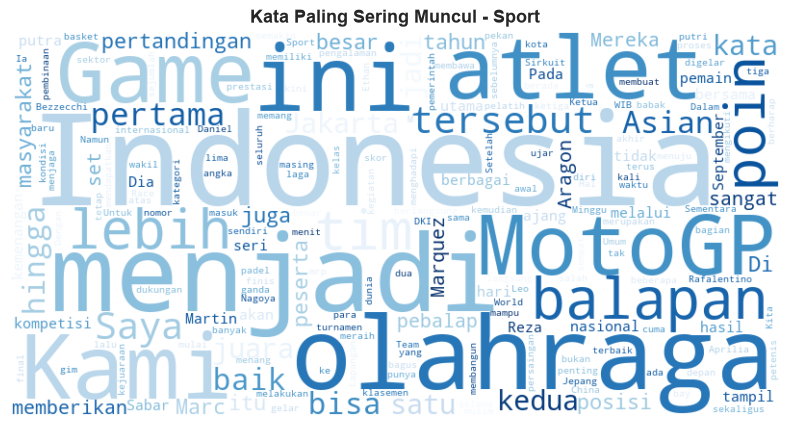

In [43]:
from wordcloud import WordCloud
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

text_sport = stopword_remover.remove(" ".join(df[df["label"] == "sport"]["isi_berita"]))
wc_sport = WordCloud(width=800, height=400, background_color="white",
                      colormap="Blues", collocations=False).generate(text_sport)

plt.figure(figsize=(10, 5))
plt.imshow(wc_sport, interpolation="bilinear")
plt.axis("off")
plt.title("Kata Paling Sering Muncul - Sport", fontsize=13, fontweight="bold")
plt.show()

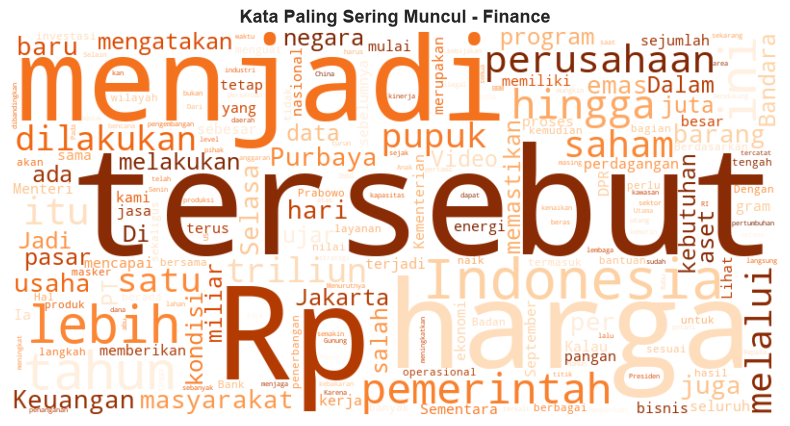

In [44]:
text_finance = stopword_remover.remove(" ".join(df[df["label"] == "finance"]["isi_berita"]))
wc_finance = WordCloud(width=800, height=400, background_color="white",
                        colormap="Oranges", collocations=False).generate(text_finance)

plt.figure(figsize=(10, 5))
plt.imshow(wc_finance, interpolation="bilinear")
plt.axis("off")
plt.title("Kata Paling Sering Muncul - Finance", fontsize=13, fontweight="bold")
plt.show()

### Contoh Artikel

In [45]:
contoh_sport = df[df["label"]=="sport"].sample(1, random_state=1).iloc[0]
contoh_finance = df[df["label"]=="finance"].sample(1, random_state=1).iloc[0]

print("=== CONTOH ARTIKEL SPORT ===")
print(contoh_sport["isi_berita"][:400], "...\n")

print("=== CONTOH ARTIKEL FINANCE ===")
print(contoh_finance["isi_berita"][:400], "...")

=== CONTOH ARTIKEL SPORT ===
Bilal Hasan memulai debut di UFC dengan meyakinkan, menang KO. Legenda UFC, Henry Cejudo dibikin kagum olehnya.
UFC Fight Night: Nurmagomedov vs Song dalam UFC Shanghai digelar di Oriental Sports Center, Sabtu (29/8). Bilal Hasan yang jalani laga debut, hadapi petarung asal Peru, Nilson Rojas di kelas flyweight.
Kedua petarung punya rekor sama 9-0. Bilal menang di ronde kedua setelah pukulan lurus ...

=== CONTOH ARTIKEL FINANCE ===
Seluruh bandara yang sebelumnya terdampak erupsi Gunung Anak Krakatau kembali dibuka untuk operasional penerbangan. Berdasarkan pembaruan Kantor Otoritas Bandar Udara Wilayah I Kelas Utama, terdapat delapan bandara yang telah kembali beroperasi.
Informasi tersebut disampaikan melalui pembaruan operasional penerbangan per Selasa (8/9/2026) pukul 10.00 WIB. Pembukaan dilakukan setelah sebelumnya ope ...


## 4. Verify Data Quality

### Analisis Outlier (Panjang Teks)

Menggunakan metode IQR (Interquartile Range) untuk mengidentifikasi artikel dengan panjang teks yang jauh berbeda dari mayoritas data — bisa jadi indikasi artikel yang terlalu pendek (ekstraksi gagal sebagian) atau terlalu panjang (artikel liputan khusus/mendalam).

In [46]:
def cek_outlier(data, label):
    q1 = data["panjang_teks"].quantile(0.25)
    q3 = data["panjang_teks"].quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr

    outlier = data[(data["panjang_teks"] < batas_bawah) | (data["panjang_teks"] > batas_atas)]
    print(f"[{label}] Batas normal: {batas_bawah:.0f} - {batas_atas:.0f} karakter")
    print(f"[{label}] Jumlah outlier: {len(outlier)} dari {len(data)} artikel\n")
    return outlier

outlier_sport = cek_outlier(df[df["label"] == "sport"], "sport")
outlier_finance = cek_outlier(df[df["label"] == "finance"], "finance")

[sport] Batas normal: 314 - 4020 karakter
[sport] Jumlah outlier: 4 dari 100 artikel

[finance] Batas normal: 391 - 4348 karakter
[finance] Jumlah outlier: 12 dari 100 artikel



In [47]:
semua_outlier = pd.concat([outlier_sport, outlier_finance])
if len(semua_outlier) > 0:
    print(f"Detail {len(semua_outlier)} artikel outlier:")
    display(semua_outlier[["id", "label", "panjang_teks"]])
else:
    print("Tidak ditemukan outlier ekstrem pada dataset.")

Detail 16 artikel outlier:


,id,label,panjang_teks
12,13,sport,4021
57,58,sport,5554
60,61,sport,4144
98,99,sport,4070
114,115,finance,5760
116,117,finance,8169
118,119,finance,4508
123,124,finance,5384
127,128,finance,4823
140,141,finance,5704


**Takeaway:** Outlier yang terdeteksi masih berupa artikel dengan konten memang lebih panjang/pendek secara wajar (misalnya liputan mendalam vs berita singkat), bukan hasil kegagalan ekstraksi — sehingga tidak perlu dihapus dari dataset.

## Ringkasan Data Understanding

- Dataset terdiri dari 200 artikel, seimbang antara kategori `sport` (100) dan `finance` (100).
- Tidak ditemukan nilai kosong maupun duplikat pada kolom `isi_berita`.
- Artikel sport didominasi sub-kategori seperti sepakbola dan basket, sementara finance didominasi berita ekonomi-bisnis dan moneter.
- Panjang artikel finance sedikit lebih panjang rata-rata dan lebih bervariasi dibanding sport, terlihat jelas dari histogram dan boxplot.
- Dataset dinyatakan **siap** untuk tahap Data Preparation.